# Q-learning Experiments

This notebook runs the Phase 1 Q-learning baseline for the static maze environment.

It covers:

- environment inspection
- tabular Q-learning training
- greedy evaluation
- metrics summary
- Q-table saving
- learning and policy visualizations when matplotlib is available

Only Q-learning is used here. DQN, PPO, and SAC are intentionally left out.

## 1. Notebook Setup

Run this first so imports work whether the notebook is opened from the project root or from the `notebooks/` folder.

In [2]:
from pathlib import Path
import sys

PROJECT_ROOT = Path.cwd()
if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

PROJECT_ROOT

PosixPath('/home/hiba/Desktop/Maze-and-Path-Finding-main 1/Maze-and-Path-Finding-main')

In [3]:
%pip install matplotlib seaborn scikit-learn pandas numpy

Note: you may need to restart the kernel to use updated packages.


In [4]:
import json
import numpy as np

from src.agents import QLearningAgent
from src.env import LEVEL_SIZES, MazeEnv, ACTION_NAMES
from src.training.evaluator import evaluate_qlearning
from src.training.trainer_qlearning import train_qlearning, rollout_greedy_path
from src.utils.io import DIRS, ensure_dirs, figure_path, save_metrics, save_qtable
from src.utils.seed import set_global_seed

ensure_dirs()
print("Imports ready")

Imports ready


## 2. Experiment Configuration

For a fast test, set `EPISODES = 20` or `100`. For the actual baseline, use `EPISODES = 5000`.

In [19]:
LEVEL = "small"  # tiny=8, small=10, medium=20, large=50
SIZE = LEVEL_SIZES[LEVEL]
DIFFICULTY = "hard"  # easy, medium, hard
SEED = 42
EPISODES = 500
LOG_EVERY = 100

ALPHA = 0.1
GAMMA = 0.99
EPSILON_START = 1.0
EPSILON_END = 0.01
EPSILON_DECAY = 0.995

RUN_ID = f"qlearning_{LEVEL}_{DIFFICULTY}_seed{SEED}"
RUN_ID

'qlearning_small_hard_seed42'

## 3. Create and Inspect the Maze Environment

In [20]:
set_global_seed(SEED)

env = MazeEnv(level=LEVEL, difficulty=DIFFICULTY, seed=SEED)
env.action_space.seed(SEED)

obs, info = env.reset()

print("Level:", env.level)
print("Difficulty:", env.difficulty)
print("Maze size:", env.size)
print("Observation shape:", obs.shape)
print("Action space:", env.action_space.n)
print("Start:", env.start_pos)
print("Goal:", env.goal_pos)
print("Max steps:", env.max_steps)
print("Optimal path length:", info["optimal_path_len"])
print("Actions:", ACTION_NAMES)

Level: small
Difficulty: hard
Maze size: 10
Observation shape: (100,)
Action space: 4
Start: (0, 0)
Goal: (9, 9)
Max steps: 400
Optimal path length: 28
Actions: {0: 'Up', 1: 'Down', 2: 'Left', 3: 'Right'}


In [21]:
env.maze

array([[0, 0, 1, 1, 0, 1, 0, 0, 0, 0],
       [0, 0, 1, 1, 0, 0, 0, 0, 0, 0],
       [0, 1, 1, 1, 0, 0, 0, 1, 1, 0],
       [0, 0, 0, 1, 0, 0, 0, 1, 1, 0],
       [0, 0, 0, 1, 0, 0, 1, 1, 0, 0],
       [0, 0, 0, 0, 0, 0, 1, 1, 0, 0],
       [0, 0, 0, 0, 0, 0, 1, 1, 0, 1],
       [1, 0, 0, 0, 0, 1, 1, 1, 0, 0],
       [0, 1, 1, 0, 1, 0, 0, 0, 0, 0],
       [0, 0, 0, 1, 0, 0, 0, 0, 0, 0]], dtype=int32)

Optional maze display. If matplotlib has a NumPy compatibility problem in your environment, skip this cell.

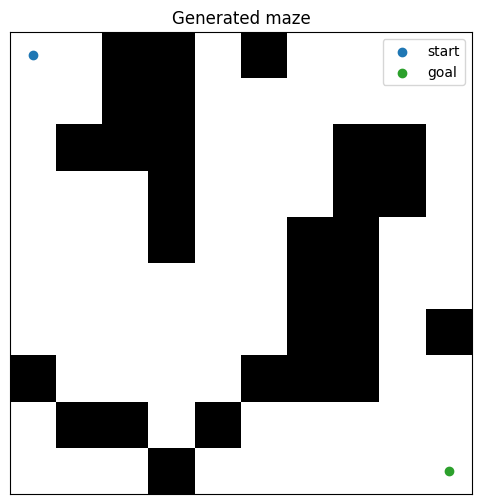

In [22]:
try:
    import matplotlib.pyplot as plt

    plt.figure(figsize=(6, 6))
    plt.imshow(env.maze, cmap="binary")
    plt.scatter([env.start_pos[1]], [env.start_pos[0]], c="tab:blue", label="start")
    plt.scatter([env.goal_pos[1]], [env.goal_pos[0]], c="tab:green", label="goal")
    plt.xticks([])
    plt.yticks([])
    plt.title("Generated maze")
    plt.legend()
    plt.show()
except Exception as exc:
    print("Plot skipped:", exc)

## 4. Create the Q-learning Agent

In [23]:
agent = QLearningAgent(
    n_states=env.size * env.size,
    n_actions=env.action_space.n,
    learning_rate=ALPHA,
    gamma=GAMMA,
    epsilon_start=EPSILON_START,
    epsilon_end=EPSILON_END,
    epsilon_decay=EPSILON_DECAY,
    seed=SEED,
)

print("Q-table shape:", agent.q_table.shape)
print("Initial epsilon:", agent.epsilon)

Q-table shape: (100, 4)
Initial epsilon: 1.0


## 5. Train Q-learning

This cell can take longer when `EPISODES = 5000`. For quick debugging, reduce the value in the configuration cell.

In [24]:
result = train_qlearning(
    env=env,
    agent=agent,
    episodes=EPISODES,
    log_every=LOG_EVERY,
    logger=None,
    capture_paths=True,
)

summary = result.tracker.compute_summary()
summary

Episode   100/500 | return= -9.030 | steps= 122 | success=1 | eps=0.609 | rolling_success=71.00%
Episode   200/500 | return= -1.370 | steps=  42 | success=1 | eps=0.369 | rolling_success=100.00%
Episode   300/500 | return= -0.910 | steps=  45 | success=1 | eps=0.223 | rolling_success=100.00%
Episode   400/500 | return= -0.770 | steps=  31 | success=1 | eps=0.135 | rolling_success=100.00%
Episode   500/500 | return=  0.670 | steps=  34 | success=1 | eps=0.082 | rolling_success=100.00%


{'success_rate': 1.0,
 'mean_return': 0.1652,
 'std_return': 0.5613,
 'mean_steps_to_goal': 31.56,
 'std_steps_to_goal': 2.99,
 'convergence_episode': 122,
 'sample_efficiency': 26668.0,
 'path_optimality': 0.8872,
 'optimal_path_len': 28,
 'total_episodes': 500}

## 6. Evaluate the Greedy Policy

Evaluation uses `training=False`, so the agent acts greedily with no epsilon exploration.

In [25]:
eval_result = evaluate_qlearning(env, agent, episodes=100)

eval_summary = {
    "eval_success_rate": round(eval_result.success_rate, 4),
    "eval_mean_return": round(eval_result.mean_return, 4),
    "eval_mean_steps": round(eval_result.mean_steps, 2),
}

eval_summary

{'eval_success_rate': 1.0, 'eval_mean_return': 0.73, 'eval_mean_steps': 28.0}

## 7. Save Experiment Outputs

In [26]:
full_summary = {
    **summary,
    **eval_summary,
    "maze_size": env.size,
    "max_steps": env.max_steps,
    "run_id": RUN_ID,
}

qtable_path = save_qtable(agent.q_table, RUN_ID)
metrics_path = save_metrics(
    {
        "episodes": result.tracker.episodes_arr,
        "rewards": result.tracker.rewards,
        "steps": result.tracker.steps_arr,
        "success": result.tracker.success_arr,
    },
    RUN_ID,
)

summary_path = DIRS["logs"] / f"{RUN_ID}_notebook_summary.json"
summary_path.write_text(json.dumps(full_summary, indent=2, default=str), encoding="utf-8")

paths_path = DIRS["metrics"] / f"{RUN_ID}_notebook_paths.json"
paths_json = {
    name: [[int(r), int(c)] for r, c in path]
    for name, path in result.paths.items()
}
paths_path.write_text(json.dumps(paths_json, indent=2), encoding="utf-8")

print("Q-table:", qtable_path)
print("Metrics:", metrics_path)
print("Summary:", summary_path)
print("Paths:", paths_path)

  [io] Q-table saved -> /home/hiba/Desktop/Maze-and-Path-Finding-main 1/Maze-and-Path-Finding-main/models/qlearning/qlearning_small_hard_seed42.npy
  [io] metrics saved -> /home/hiba/Desktop/Maze-and-Path-Finding-main 1/Maze-and-Path-Finding-main/results/metrics/qlearning_small_hard_seed42_metrics.npz
Q-table: /home/hiba/Desktop/Maze-and-Path-Finding-main 1/Maze-and-Path-Finding-main/models/qlearning/qlearning_small_hard_seed42.npy
Metrics: /home/hiba/Desktop/Maze-and-Path-Finding-main 1/Maze-and-Path-Finding-main/results/metrics/qlearning_small_hard_seed42_metrics.npz
Summary: /home/hiba/Desktop/Maze-and-Path-Finding-main 1/Maze-and-Path-Finding-main/results/logs/qlearning_small_hard_seed42_notebook_summary.json
Paths: /home/hiba/Desktop/Maze-and-Path-Finding-main 1/Maze-and-Path-Finding-main/results/metrics/qlearning_small_hard_seed42_notebook_paths.json


## 8. Learning Curves

/tmp/ipykernel_175610/119325699.py:6: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig1.show()
/tmp/ipykernel_175610/119325699.py:10: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig2.show()


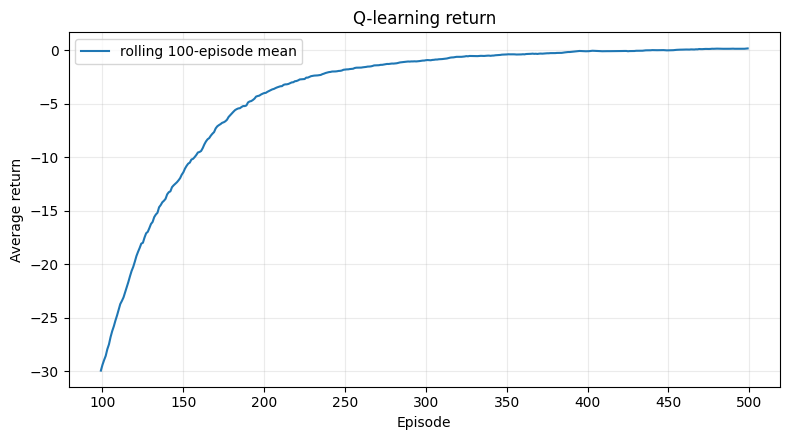

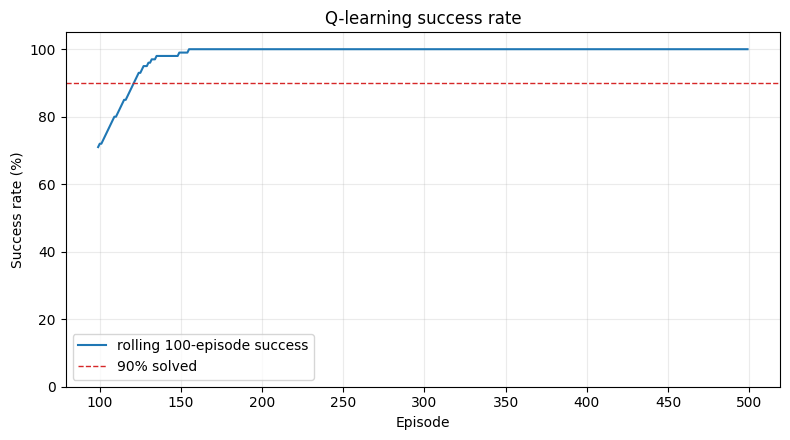

In [27]:
try:
    from src.visualization.plots import plot_learning_curve, plot_success_curve

    fig1 = plot_learning_curve(result.tracker.rewards, window=100)
    fig1.savefig(figure_path(RUN_ID, "notebook_learning_curve"), dpi=150)
    fig1.show()

    fig2 = plot_success_curve(result.tracker.success_arr, window=100)
    fig2.savefig(figure_path(RUN_ID, "notebook_success_curve"), dpi=150)
    fig2.show()
except Exception as exc:
    print("Plot skipped:", exc)

## 9. Q-value Heatmap and Policy Map

/tmp/ipykernel_175610/3563132546.py:7: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig3.show()
/tmp/ipykernel_175610/3563132546.py:11: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig4.show()


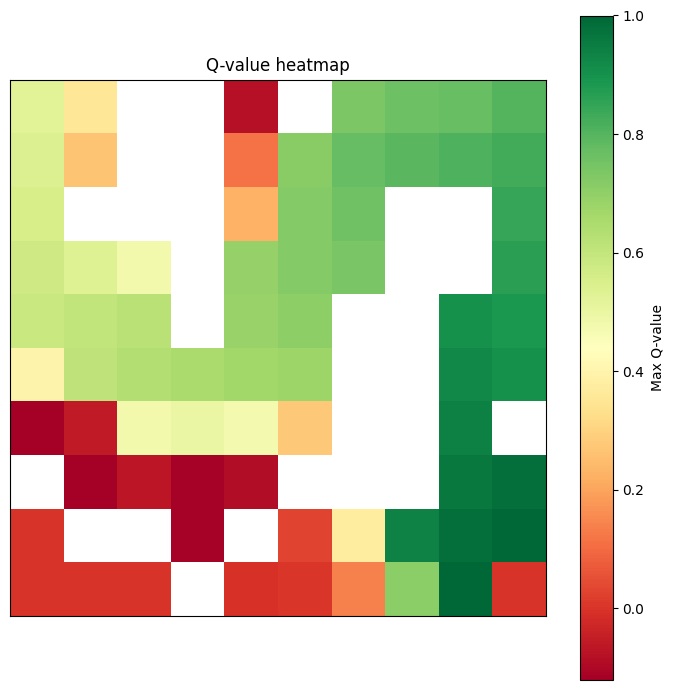

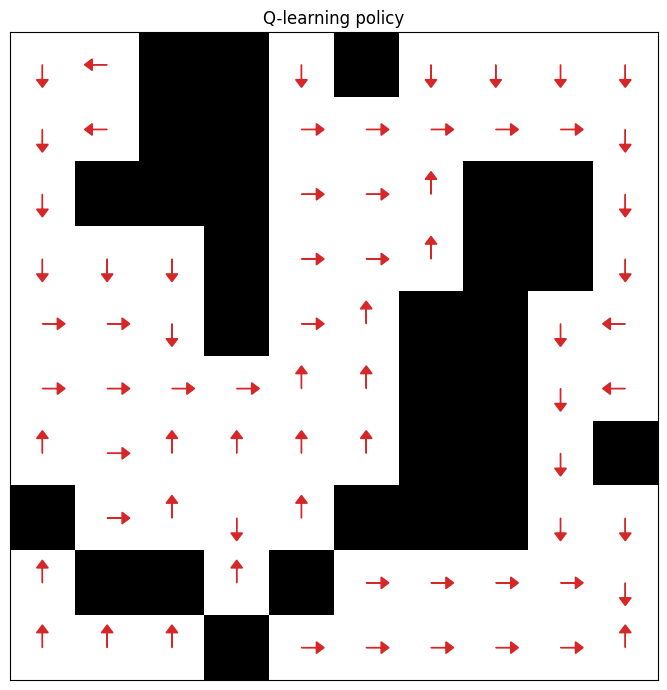

In [14]:
try:
    from src.visualization.heatmaps import plot_q_heatmap
    from src.visualization.policy_maps import plot_policy_arrows

    fig3 = plot_q_heatmap(agent.q_table, env.maze)
    fig3.savefig(figure_path(RUN_ID, "notebook_q_heatmap"), dpi=150)
    fig3.show()

    fig4 = plot_policy_arrows(agent.q_table, env.maze)
    fig4.savefig(figure_path(RUN_ID, "notebook_policy_map"), dpi=150)
    fig4.show()
except Exception as exc:
    print("Plot skipped:", exc)

## 10. Inspect a Greedy Path

In [15]:
greedy_path = rollout_greedy_path(env, agent)

print("Greedy path length:", len(greedy_path) - 1)
print("Reached goal:", greedy_path[-1] == env.goal_pos)
print("First 20 positions:")
greedy_path[:20]

Greedy path length: 28
Reached goal: True
First 20 positions:


[(0, 0),
 (1, 0),
 (2, 0),
 (3, 0),
 (4, 0),
 (4, 1),
 (4, 2),
 (5, 2),
 (5, 3),
 (5, 4),
 (4, 4),
 (4, 5),
 (3, 5),
 (3, 6),
 (2, 6),
 (1, 6),
 (1, 7),
 (1, 8),
 (1, 9),
 (2, 9)]

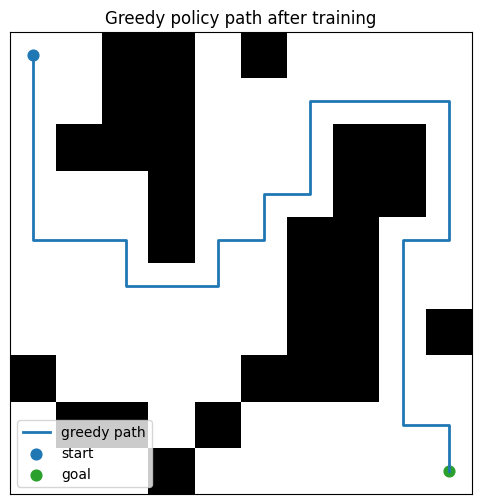

In [16]:
try:
    import matplotlib.pyplot as plt

    ys = [r for r, c in greedy_path]
    xs = [c for r, c in greedy_path]

    plt.figure(figsize=(6, 6))
    plt.imshow(env.maze, cmap="binary")
    plt.plot(xs, ys, color="tab:blue", linewidth=2, label="greedy path")
    plt.scatter([env.start_pos[1]], [env.start_pos[0]], c="tab:blue", s=60, label="start")
    plt.scatter([env.goal_pos[1]], [env.goal_pos[0]], c="tab:green", s=60, label="goal")
    plt.xticks([])
    plt.yticks([])
    plt.legend()
    plt.title("Greedy policy path after training")
    plt.show()
except Exception as exc:
    print("Plot skipped:", exc)

## 11. Compare Multiple Seeds

Use this optional cell to run the same Q-learning experiment over several seeds. This is useful for reporting mean and variance in your paper.

For a real experiment, keep `multi_seed_episodes = 5000`.

In [17]:
RUN_MULTI_SEED = False
multi_seed_episodes = 5000
seeds = [1, 2, 3, 4, 5]

multi_seed_results = []

if RUN_MULTI_SEED:
    for seed in seeds:
        set_global_seed(seed)
        seed_env = MazeEnv(level=LEVEL, difficulty=DIFFICULTY, seed=seed)
        seed_env.action_space.seed(seed)
        seed_agent = QLearningAgent(
            n_states=seed_env.size * seed_env.size,
            n_actions=seed_env.action_space.n,
            learning_rate=ALPHA,
            gamma=GAMMA,
            epsilon_start=EPSILON_START,
            epsilon_end=EPSILON_END,
            epsilon_decay=EPSILON_DECAY,
            seed=seed,
        )
        seed_result = train_qlearning(
            seed_env,
            seed_agent,
            episodes=multi_seed_episodes,
            log_every=0,
        )
        seed_eval = evaluate_qlearning(seed_env, seed_agent, episodes=100)
        seed_summary = seed_result.tracker.compute_summary()
        seed_summary.update(
            {
                "seed": seed,
                "eval_success_rate": seed_eval.success_rate,
                "eval_mean_return": seed_eval.mean_return,
                "eval_mean_steps": seed_eval.mean_steps,
            }
        )
        multi_seed_results.append(seed_summary)

multi_seed_results

[]

## 12. Multi-seed Summary

Run this after the previous cell if `RUN_MULTI_SEED = True`.

In [18]:
if multi_seed_results:
    success_rates = np.array([r["eval_success_rate"] for r in multi_seed_results], dtype=float)
    returns = np.array([r["eval_mean_return"] for r in multi_seed_results], dtype=float)
    steps = np.array([r["eval_mean_steps"] for r in multi_seed_results], dtype=float)

    aggregate = {
        "success_rate_mean": float(np.mean(success_rates)),
        "success_rate_std": float(np.std(success_rates)),
        "return_mean": float(np.mean(returns)),
        "return_std": float(np.std(returns)),
        "steps_mean": float(np.mean(steps)),
        "steps_std": float(np.std(steps)),
    }
else:
    aggregate = "Set RUN_MULTI_SEED = True and run the previous cell first."

aggregate

'Set RUN_MULTI_SEED = True and run the previous cell first.'